In [2]:
# import necessary libraries

#used for data analysis
import pandas as pd
import numpy as np

# used for data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Data Pre-processing 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Classifier libraries
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

#pip install xgboost
from xgboost import XGBClassifier 
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import GaussianNB 
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

#Evaluation metrics
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score 
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load Dataset
df = pd.read_csv(r"C:\Users\Real One\Downloads\heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
# Rename columns
df.columns = ['age','sex','chest_pain_type','resting_blood_pressure','cholesterol','fasting_blood_sugar','rest_ecg','max_heart_rate_achieved','exercise_induced_angina','st_depression','st_slope','num_major_vessels','thalassemia','target']
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      303 non-null    int64  
 1   sex                      303 non-null    int64  
 2   chest_pain_type          303 non-null    int64  
 3   resting_blood_pressure   303 non-null    int64  
 4   cholesterol              303 non-null    int64  
 5   fasting_blood_sugar      303 non-null    int64  
 6   rest_ecg                 303 non-null    int64  
 7   max_heart_rate_achieved  303 non-null    int64  
 8   exercise_induced_angina  303 non-null    int64  
 9   st_depression            303 non-null    float64
 10  st_slope                 303 non-null    int64  
 11  num_major_vessels        303 non-null    int64  
 12  thalassemia              303 non-null    int64  
 13  target                   303 non-null    int64  
dtypes: float64(1), int64(13)
m

In [6]:
# statistical analysis
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
chest_pain_type,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
resting_blood_pressure,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
cholesterol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fasting_blood_sugar,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
rest_ecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
max_heart_rate_achieved,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exercise_induced_angina,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
st_depression,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


<AxesSubplot:>

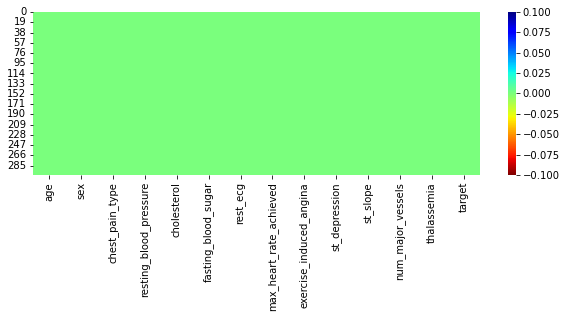

In [7]:
#checking for missing values
df.isnull().sum()

# visualizing missing data
plt.figure(figsize=(10,3))
sns.heatmap(df.isnull(), cbar=True, cmap='jet_r')

## Exploratory Data Analysis

### Univariate analysis

In [8]:
df.columns

Index(['age', 'sex', 'chest_pain_type', 'resting_blood_pressure',
       'cholesterol', 'fasting_blood_sugar', 'rest_ecg',
       'max_heart_rate_achieved', 'exercise_induced_angina', 'st_depression',
       'st_slope', 'num_major_vessels', 'thalassemia', 'target'],
      dtype='object')

<AxesSubplot:xlabel='thalassemia'>

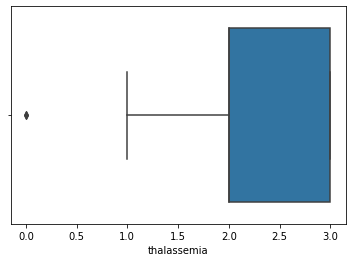

In [9]:
# check for outliers
sns.boxplot(x=df['thalassemia'])

<AxesSubplot:xlabel='resting_blood_pressure'>

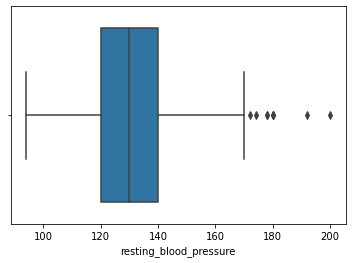

In [10]:
# check for outliers
sns.boxplot(x=df['resting_blood_pressure'])

<AxesSubplot:xlabel='cholesterol'>

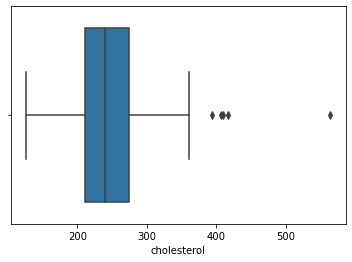

In [11]:
# check for outliers
sns.boxplot(x=df['cholesterol'])

<AxesSubplot:xlabel='max_heart_rate_achieved'>

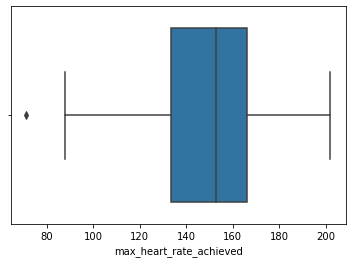

In [12]:
# check for outliers
sns.boxplot(x=df['max_heart_rate_achieved'])

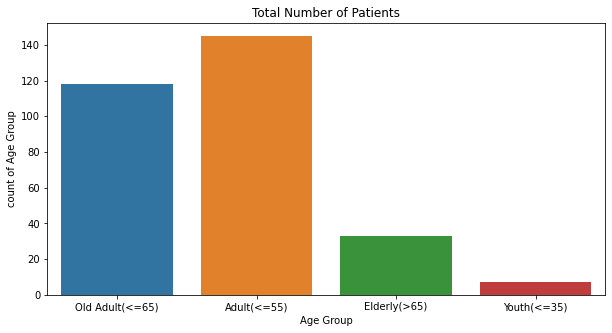

In [13]:
#Data Visualization
#Age_bracket
def age_bracket(age):
    if age <= 35:
        return 'Youth(<=35)'
    elif age <= 55:
        return 'Adult(<=55)'
    elif age <= 65:
        return 'Old Adult(<=65)'
    else:
        return 'Elderly(>65)'
df['age_bracket'] = df['age'].apply(age_bracket)

#Investigating the age group of patients
plt.figure(figsize = (10,5))
sns.countplot(x='age_bracket',data=df)
plt.xlabel('Age Group')
plt.ylabel('count of Age Group')
plt.title('Total Number of Patients');

Text(0.5, 1.0, 'Total Number of Patients')

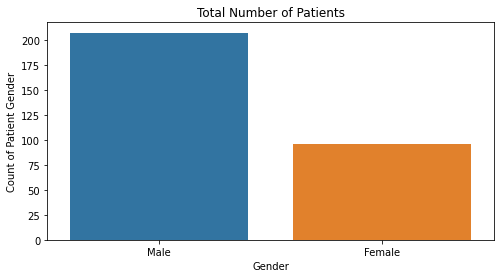

In [14]:
#Data Visualization
#Sex
def gender(sex):
    if sex == 1:
        return "Male"
    else:
        return "Female"
df['gender'] = df['sex'].apply(gender)

#Investigating the gender of patients
plt.figure(figsize =(8,4))
sns.countplot(x='gender',data=df)
plt.xlabel('Gender')
plt.ylabel('Count of Patient Gender')
plt.title('Total Number of Patients')

Text(0.5, 1.0, 'Total Number of Patients')

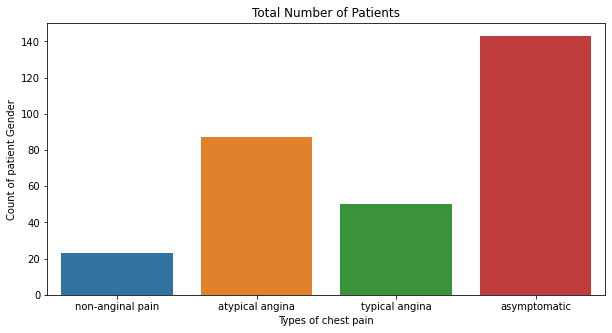

In [15]:
#Data Visualization
# chest pain type (1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic)
def chest_pain(cp):
    if cp == 1:
        return 'typical angina'
    elif cp == 2:
        return 'atypical angina'
    elif cp == 3:
        return 'non-anginal pain'
    else:
        return 'asymptomatic'
    
df['cp_cat'] = df['chest_pain_type'].apply(chest_pain)

#Investigating the gender of patients
plt.figure(figsize = (10,5))
sns.countplot(x='cp_cat',data=df)
plt.xlabel('Types of chest pain')
plt.ylabel('Count of patient Gender')
plt.title('Total Number of Patients')

Text(0.5, 1.0, 'Total Number of Patients')

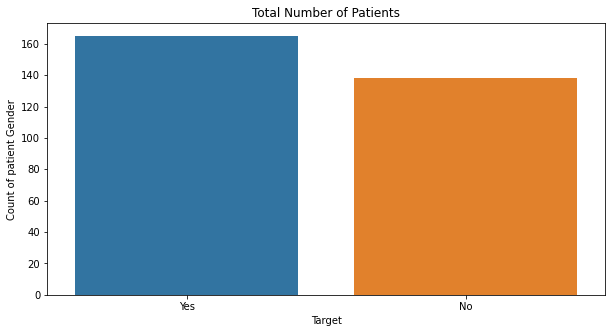

In [16]:
#Data visualization
#target
def label(tg):
    if tg == 1:
        return 'Yes'
    else:
        return 'No'

df['label'] = df['target'].apply(label)

#investigating the target of patients
plt.figure(figsize = (10,5))
sns.countplot(x='label',data=df)
plt.xlabel('Target')
plt.ylabel('Count of patient Gender')
plt.title('Total Number of Patients')

### Bivariate Analysis

Text(0.5, 1.0, "Categorisation of Patient's chest pain by age")

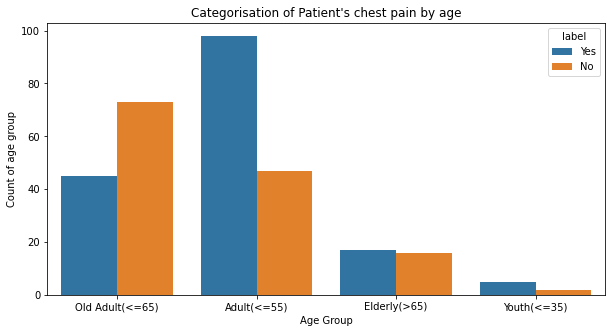

In [17]:
plt.figure(figsize = (10,5))
sns.countplot(x='age_bracket',data=df, hue = 'label')
plt.xlabel('Age Group')
plt.ylabel('Count of age group')
plt.title("Categorisation of Patient's chest pain by age")

Text(0.5, 1.0, 'Categorisation of Patient chest pain by Gender')

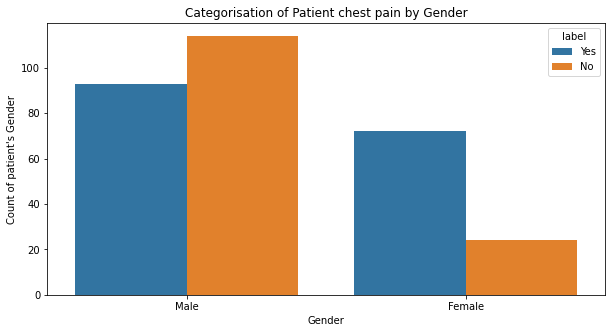

In [18]:
plt.figure(figsize = (10,5))
sns.countplot(x='gender',data=df, hue = 'label')
plt.xlabel('Gender')
plt.ylabel("Count of patient's Gender")
plt.title('Categorisation of Patient chest pain by Gender')

Text(0.5, 1.0, "Categorisation of patient's by chest pain type")

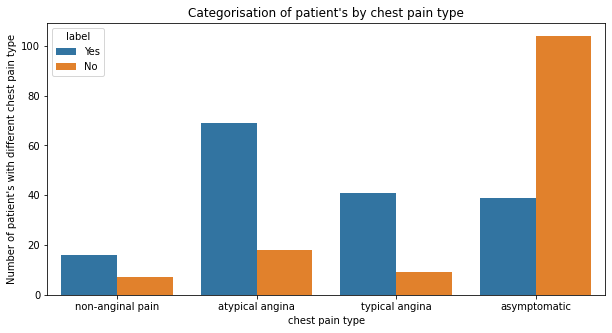

In [19]:
plt.figure(figsize = (10,5))
sns.countplot(x='cp_cat',data=df, hue = 'label')
plt.xlabel('chest pain type')
plt.ylabel("Number of patient's with different chest pain type")
plt.title("Categorisation of patient's by chest pain type")

### Multivariate Analysis

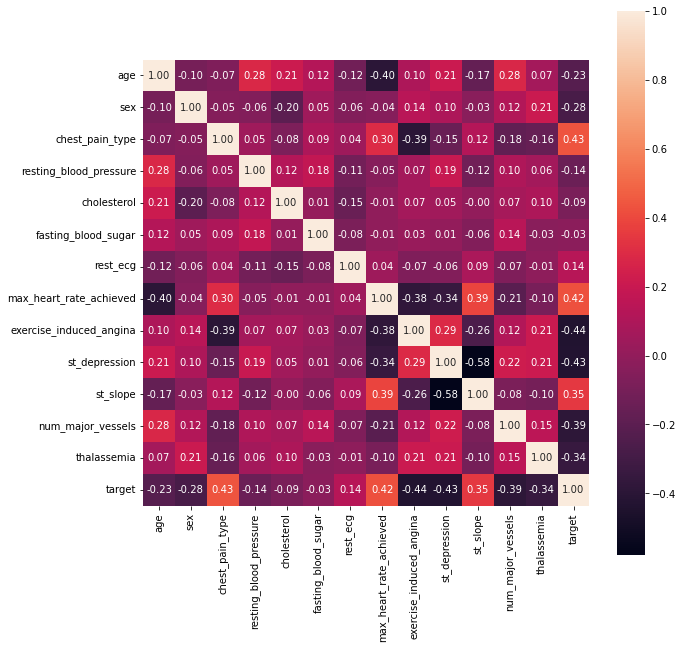

In [20]:
#Correlation between Target and other variables in the dataset
plt.figure(figsize = (10,10))

hm = sns.heatmap(df.corr(), cbar = True, annot = True, square=True, fmt='.2f', annot_kws={'size':10})

## Feature engineering/Data Pre-processing 

In [21]:
#create a copy of the data(exclude target/label including the columns that were created.)
df1 = df[['age', 'sex', 'chest_pain_type', 'resting_blood_pressure',
       'cholesterol', 'fasting_blood_sugar', 'rest_ecg',
       'max_heart_rate_achieved', 'exercise_induced_angina', 'st_depression',
       'st_slope', 'num_major_vessels', 'thalassemia']]

label1 = df['target']

In [22]:
df1.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate_achieved,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [23]:
label1.head()

0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64

In [24]:
df1.dtypes

age                          int64
sex                          int64
chest_pain_type              int64
resting_blood_pressure       int64
cholesterol                  int64
fasting_blood_sugar          int64
rest_ecg                     int64
max_heart_rate_achieved      int64
exercise_induced_angina      int64
st_depression              float64
st_slope                     int64
num_major_vessels            int64
thalassemia                  int64
dtype: object

In [25]:
df.columns

Index(['age', 'sex', 'chest_pain_type', 'resting_blood_pressure',
       'cholesterol', 'fasting_blood_sugar', 'rest_ecg',
       'max_heart_rate_achieved', 'exercise_induced_angina', 'st_depression',
       'st_slope', 'num_major_vessels', 'thalassemia', 'target', 'age_bracket',
       'gender', 'cp_cat', 'label'],
      dtype='object')

In [26]:
#Dealing with outliers: 'resting_blood_pressure','cholesterol','thalassemia'

#Normalize the data
scaler = MinMaxScaler()
df1['scaled_RBP'] = scaler.fit_transform(df1['resting_blood_pressure'].values.reshape(-1,1))
df1['scaled_chol'] = scaler.fit_transform(df1['cholesterol'].values.reshape(-1,1))
df1['scaled_thal'] = scaler.fit_transform(df1['thalassemia'].values.reshape(-1,1))
df1['scaled_max_heart_rate'] = scaler.fit_transform(df1['max_heart_rate_achieved'].values.reshape(-1,1))

df1.drop(['resting_blood_pressure','cholesterol','thalassemia','max_heart_rate_achieved'], axis=1, inplace=True)

df1.head()

,age,sex,chest_pain_type,fasting_blood_sugar,rest_ecg,exercise_induced_angina,st_depression,st_slope,num_major_vessels,scaled_RBP,scaled_chol,scaled_thal,scaled_max_heart_rate
0,63,1,3,1,0,0,2.3,0,0,0.481132,0.244292,0.333333,0.603053
1,37,1,2,0,1,0,3.5,0,0,0.339623,0.283105,0.666667,0.885496
2,41,0,1,0,0,0,1.4,2,0,0.339623,0.178082,0.666667,0.770992
3,56,1,1,0,1,0,0.8,2,0,0.245283,0.251142,0.666667,0.816794
4,57,0,0,0,1,1,0.6,2,0,0.245283,0.520548,0.666667,0.702290


## Machining learning

In [27]:
# Split the dataset into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(df1,label1,test_size=0.2, random_state=42)

# Note: Everything X = questions, y = Answers

In [28]:
# Model Building 
# Logistic Regression

logreg = LogisticRegression()
logreg.fit(X_train, y_train)
ly_pred = logreg.predict(X_test)

print('Logistic Regression')
print("Accuracy: ", accuracy_score(y_test, ly_pred))
print("Precision: ", precision_score(y_test,ly_pred))
print("Recall: ", recall_score(y_test,ly_pred))
print("f1_score: ", f1_score(y_test,ly_pred))
print("AUC_ROC: ", roc_auc_score(y_test,ly_pred))

print('The number of accurate predictions: ', accuracy_score(y_test, ly_pred, normalize = False))

Logistic Regression
Accuracy:  0.8524590163934426
Precision:  0.8709677419354839
Recall:  0.84375
f1_score:  0.8571428571428571
AUC_ROC:  0.8529094827586207
The number of accurate predictions:  52.0


<AxesSubplot:>

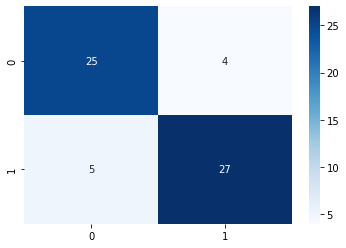

In [29]:
# Create a confusion matrix

lcm = confusion_matrix(y_test, ly_pred)

#Visualize the confusion matrix
sns.heatmap(lcm, annot=True, cmap='Blues',fmt='g')

In [30]:
# Random Forest Classifier

rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)
rfy_pred = rfc.predict(X_test)

print('Random Forest Classifier')
print("Accuracy: ", accuracy_score(y_test, rfy_pred)*100)
print("Precision: ", precision_score(y_test,rfy_pred))
print("Recall: ", recall_score(y_test,rfy_pred))
print("f1_score: ", f1_score(y_test,rfy_pred))
print("AUC_ROC: ", roc_auc_score(y_test,rfy_pred))

print('The number of accurate predictions: ', accuracy_score(y_test, rfy_pred, normalize = False))

Random Forest Classifier
Accuracy:  86.88524590163934
Precision:  0.8529411764705882
Recall:  0.90625
f1_score:  0.8787878787878788
AUC_ROC:  0.8669181034482758
The number of accurate predictions:  53.0


<AxesSubplot:>

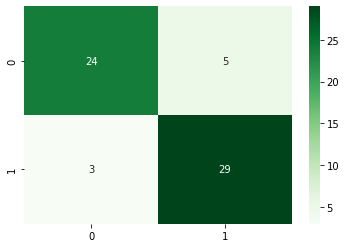

In [31]:
# confusion matrix

rcm = confusion_matrix(y_test, rfy_pred)

#visualize the confusion matrix

sns.heatmap(rcm, annot=True, cmap='Greens',fmt='g')

In [40]:
# How to test multiple machine learning algorithms.
# eight machine learning Algorithms will be applied to the dataset.

classifiers = [[XGBClassifier(), 'XGB classifier'],[RandomForestClassifier(),'Random Forest'],[KNeighborsClassifier(),'K-Nearest Neighbors'],[SGDClassifier(),'SGDC Classifier'],[SVC(),'SVC'],[GaussianNB(),'Naive Bayes'],[DecisionTreeClassifier(random_state = 42),'Decision Tree'],[LogisticRegression(),'Logistic Regression']
              ]


acc_list = {}
precision_list = {}
recall_list = {}
f1_score_list = {}
roc_auc_list = {}

# write a for loop that goes into the list of models to print the accuracy,precision,recall,f1_score and roc_auc in each model.

for classifier in classifiers:
    model = classifier[0]
    model.fit(X_train,y_train)
    model_name = classifier[1]
    
    pred = model.predict(X_test)
    
    a_score = accuracy_score(y_test,pred)
    p_score = precision_score(y_test,pred)
    r_score = recall_score(y_test,pred)
    f_score = f1_score(y_test,pred)
    roc_score = roc_auc_score(y_test,pred)
    
    acc_list[model_name] = str(round(a_score*100,2)) + '%'
    precision_list[model_name] = str(round(p_score*100,2)) + '%'
    recall_list[model_name] = str(round(r_score*100,2)) + '%'
    f1_score_list[model_name] = str(round(f_score*100,2)) + '%'
    roc_auc_list[model_name] = str(round(roc_score*100,2)) + '%'
    
if model_name != classifiers[-1][1]:
        print('')

In [41]:
# To print multiple variables on different lines: use the "sep='\n'"
print(acc_list,
precision_list,
recall_list,
f1_score_list,
roc_auc_list, sep='\n')

{'XGB classifier': '81.97%', 'Random Forest': '85.25%', 'K-Nearest Neighbors': '75.41%', 'SGDC Classifier': '75.41%', 'SVC': '65.57%', 'Naive Bayes': '86.89%', 'Decision Tree': '85.25%', 'Logistic Regression': '85.25%'}
{'XGB classifier': '86.21%', 'Random Forest': '84.85%', 'K-Nearest Neighbors': '79.31%', 'SGDC Classifier': '86.96%', 'SVC': '65.71%', 'Naive Bayes': '90.0%', 'Decision Tree': '92.59%', 'Logistic Regression': '87.1%'}
{'XGB classifier': '78.12%', 'Random Forest': '87.5%', 'K-Nearest Neighbors': '71.88%', 'SGDC Classifier': '62.5%', 'SVC': '71.88%', 'Naive Bayes': '84.38%', 'Decision Tree': '78.12%', 'Logistic Regression': '84.38%'}
{'XGB classifier': '81.97%', 'Random Forest': '86.15%', 'K-Nearest Neighbors': '75.41%', 'SGDC Classifier': '72.73%', 'SVC': '68.66%', 'Naive Bayes': '87.1%', 'Decision Tree': '84.75%', 'Logistic Regression': '85.71%'}
{'XGB classifier': '82.17%', 'Random Forest': '85.13%', 'K-Nearest Neighbors': '75.59%', 'SGDC Classifier': '76.08%', 'SVC': 

In [42]:
# To put the print of the 8 algorithms into a table:

v = [acc_list,precision_list,recall_list,f1_score_list,roc_auc_list]
s1 = pd.DataFrame(v, index = ['accuracy_score','precision_score','recall_score','f1_score','roc_auc_score'])
s1.head()

,XGB classifier,Random Forest,K-Nearest Neighbors,SGDC Classifier,SVC,Naive Bayes,Decision Tree,Logistic Regression
accuracy_score,81.97%,85.25%,75.41%,75.41%,65.57%,86.89%,85.25%,85.25%
precision_score,86.21%,84.85%,79.31%,86.96%,65.71%,90.0%,92.59%,87.1%
recall_score,78.12%,87.5%,71.88%,62.5%,71.88%,84.38%,78.12%,84.38%
f1_score,81.97%,86.15%,75.41%,72.73%,68.66%,87.1%,84.75%,85.71%
roc_auc_score,82.17%,85.13%,75.59%,76.08%,65.25%,87.02%,85.61%,85.29%


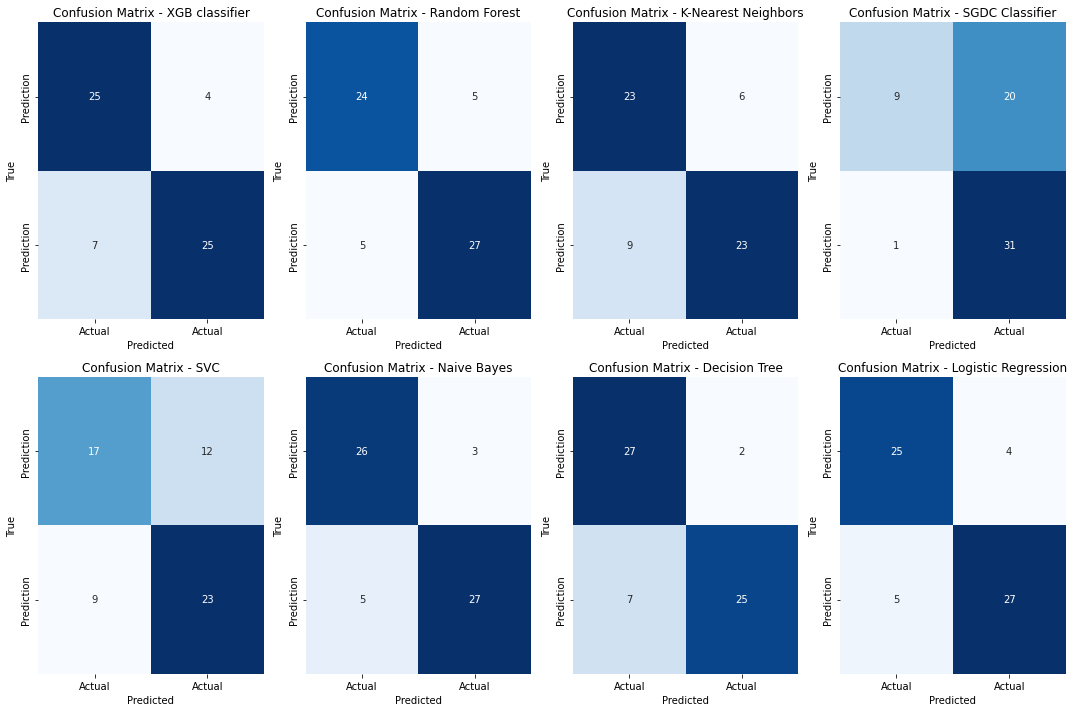

In [43]:
#classifiers = [[XGBClassifier(), 'XGB classifier'],[RandomForestClassifier(),'Random Forest'],[KNeighborsClassifier(),'K-Nearest Neighbors'],[SGDClassifier(),'SGDC Classifier'],[SVC(),'SVC'],[GaussianNB(),'Naive Bayes'],[DecisionTreeClassifier(random_state = 42),'Decision Tree'],[LogisticRegression(),'Logistic Regression']]

def plot_confusion_matrices(classifiers, X_test, y_test):
    plt.figure(figsize=(15, 10))  # Adjust the figure size as needed
    num_classifiers = len(classifiers)

    for i, (model, model_name) in enumerate(classifiers, 1):
        plt.subplot(2, (num_classifiers // 2) + (num_classifiers % 2), i)
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        cm = confusion_matrix(y_test, pred)
        sns.heatmap(cm, annot=True, cmap='Blues', fmt='g',xticklabels=['Actual', 'Actual'],yticklabels=['Prediction','Prediction'], cbar=False)
        plt.title(f'Confusion Matrix - {model_name}')
        plt.xlabel('Predicted')
        plt.ylabel('True')

    plt.tight_layout()
    plt.show()

# Usage:
# Assuming 'X_train', 'y_train', 'X_test', 'y_test' are your training and test datasets
# classifiers = [list of tuples containing (model_instance, model_name)]
# Example: classifiers = [(XGBClassifier(), 'XGB Classifier'), (RandomForestClassifier(), 'Random Forest'), ...]
plot_confusion_matrices(classifiers, X_test, y_test)